# String Methods
**Topic:** Python Fundamentals

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


---
## What you'll explore

By the end of this demo you will be able to:

- **Apply** common string methods to clean, split, and transform text values
- **Explain** why string operations in Python return new strings instead of modifying in place
- **Interpret** how the same methods scale to an entire DataFrame column via `str.method()` in pandas

---
## How we got here

In *04: Data Structures* we built a feature dictionary and saw that string columns arrive as `object` dtype in pandas. Strings are rarely clean when they arrive: column names have spaces and mixed capitalization, city names have inconsistent formatting, and free-text fields contain leading/trailing whitespace. This notebook gives you the tools to fix all of that.

---
## Why this matters for data science

Messy strings are one of the most common sources of silent errors in data pipelines. `"New York"`, `"new york"`, and `" New York "` all look similar but are treated as three distinct categories by every groupby, merge, and encoder you run. A single `.str.strip().str.lower()` chain applied at load time prevents dozens of downstream bugs. String methods are also the foundation of text feature engineering: splitting sentences into tokens, extracting substrings as new features, and flagging keywords.

---
## Try it yourself

In [2]:
# ▶ Run this cell and observe the output.
# Then try changing the values and running again.

raw = '  Total Sales ($USD)  '

print(raw.strip())           # remove leading/trailing whitespace
print(raw.lower())           # lowercase
print(raw.strip().lower())   # chain methods
print(raw.replace('$', '').replace('(', '').replace(')', ''))  # remove characters
print(raw.split())           # split on whitespace — returns a list

Total Sales ($USD)
  total sales ($usd)  
total sales ($usd)
  Total Sales USD  
['Total', 'Sales', '($USD)']


In [3]:
# ✏️ Your turn — modify this code:
# 1. Change the separator in join() from '_' to '-' and observe the result
# 2. Add .strip() before .lower() — does the order matter?
# 3. What does 'data science'.title() return? Try it.

col = '  Revenue Q3 '
words = col.strip().lower().split()
clean_col = '_'.join(words)

print(f'Original: {col!r}')
print(f'Cleaned:  {clean_col!r}')

Original: '  Revenue Q3 '
Cleaned:  'revenue_q3'


In [4]:
# 🎯 Challenge:
# Write a function called clean_column_name() that takes a messy column name
# like '  Total Sales $ ' and returns a clean version like 'total_sales'
# It should: strip whitespace, lowercase, remove special characters, join with underscores
# Hint: use a combination of .strip(), .lower(), .replace(), and .split()

# Your code here:

---
## What's happening?

Strings in Python are **immutable**: every method returns a new string rather than changing the original. This means you must assign the result back to a variable (or chain the call) to keep the transformation.

| Method | What it does | Data science use |
|--------|-------------|-----------------|
| `.strip()` | Remove leading/trailing whitespace | Clean column values after CSV import |
| `.lower()` / `.upper()` | Normalize case | Standardize categories before groupby |
| `.replace(old, new)` | Swap a substring | Remove special characters from column names |
| `.split(sep)` | Split into a list on a delimiter | Parse compound fields like `"city, state"` |
| `.startswith(prefix)` | Boolean: does the string begin with prefix? | Filter rows by prefix pattern |
| `.contains(sub)` (pandas) | Boolean mask: does the string contain sub? | Filter a DataFrame on a keyword |

```python
# Cleaning column names in one line
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)
```

### The pandas `.str` accessor applies any method element-wise

You do not need to loop over rows. `df["city"].str.lower()` applies `.lower()` to every value in the column at once, returning a new Series. This is orders of magnitude faster than a Python `for` loop for large DataFrames.

Return to the widget and compare the single-string result with the Series result to see how the same method scales.

---
## Real-world example: Inconsistent casing creates phantom duplicates

Six city entries, three real cities — but without string cleaning, pandas sees six distinct categories. The charts below show what `.value_counts()` returns before and after a `.str.strip().str.lower()` chain.

- **Notice:** Before cleaning, `"New York"` and `"new york"` are counted separately because string comparison is case-sensitive
- **Notice:** After cleaning, all three cities collapse to their correct counts
- **Notice:** The fix is a single method chain on the Series — no loop, no custom function

> **Discussion question:** A column has values like `"Yes"`, `"yes"`, `" YES "`, and `"no"`. What single method chain would normalize all of them to `"yes"` or `"no"`?

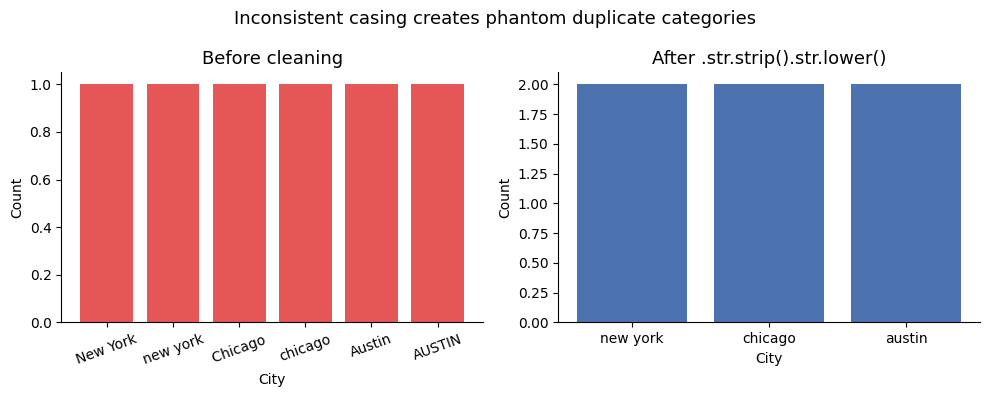

In [5]:
raw_cities = ['New York', 'new york', ' Chicago ', 'chicago', 'Austin', 'AUSTIN']
city_series = pd.Series(raw_cities)

before = city_series.value_counts()
after = city_series.str.strip().str.lower().value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(before.index, before.values, color="#E45756")
axes[0].set_title("Before cleaning", fontsize=13)
axes[0].set_xlabel("City")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=20)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].bar(after.index, after.values, color="#4C72B0")
axes[1].set_title("After .str.strip().str.lower()", fontsize=13)
axes[1].set_xlabel("City")
axes[1].set_ylabel("Count")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Inconsistent casing creates phantom duplicate categories", fontsize=13)
plt.tight_layout()
plt.show()

### High-value string operations for data cleaning

| Task | Python / pandas code | Example |
|------|---------------------|---------|
| Remove whitespace | `.str.strip()` | `" Alice "` to `"Alice"` |
| Normalize case | `.str.lower()` | `"New York"` and `"new york"` become equal |
| Replace characters | `.str.replace("-", "_")` | `"hire-date"` to `"hire_date"` |
| Extract a pattern | `.str.extract(r"(\d+)")` | `"Age: 34"` to `"34"` |
| Split a compound field | `.str.split(", ", expand=True)` | `"Austin, TX"` to two columns |
| Boolean filter | `.str.contains("error", case=False)` | Filter log messages |

---
## Key takeaway

> **String methods return new strings and never modify the original; applied through the pandas `.str` accessor they scale to millions of rows without a single explicit loop.**

---
*Next up: List Comprehensions — a concise Python syntax for transforming and filtering sequences that makes feature engineering pipelines shorter and more readable*